In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ANALYTICS_DIR  = "sálvame/trials_3000_startupfix"
ANALYTICS_DIR  = "logs/analytics"
FULL_HP        = 176
TOP_N_ACTIONS  = 20  # number of actions shown in each action distribution chart
FIGURES_DIR    = "figures"

PLAYER_COLORS = {
    "Curriculum": "#009E73",
    "Rewards":    "#882255",
    "CPU":        "#E69F00",
    "Draw":       "#8c8c8c",
}

os.makedirs(FIGURES_DIR, exist_ok=True)

matches = pd.read_csv(f"{ANALYTICS_DIR}/matches.csv")
rounds  = pd.read_csv(f"{ANALYTICS_DIR}/rounds.csv")
actions = pd.read_csv(
    f"{ANALYTICS_DIR}/actions.csv",
    dtype={"matchup": "category", "p1_name": "category", "p2_name": "category",
           "player": "category", "player_name": "category", "action": str,
           "episode": "int32", "round": "int8", "count": "int32"},
)

MATCHUPS = [
    "Curriculum_vs_CPU",
    "Rewards_vs_CPU",
    "Curriculum_vs_Rewards",
    "Rewards_vs_Curriculum",
]

print("Rows loaded:")
print(f"  matches : {len(matches):,}")
print(f"  rounds  : {len(rounds):,}")
print(f"  actions : {len(actions):,}")

Rows loaded:
  matches : 40
  rounds  : 92
  actions : 24,025


---
## 1 — Win Rate Summary

In [2]:
def pct(n, d):
    return 100 * n / d if d else 0.0

rows = []
for mu in MATCHUPS:
    p1_name, p2_name = mu.split("_vs_")
    for level, df, wcol in [
        ("match", matches[matches.matchup == mu], "match_winner"),
        ("round", rounds[rounds.matchup == mu],   "round_winner"),
    ]:
        p1   = (df[wcol] == "p1").sum()
        p2   = (df[wcol] == "p2").sum()
        draw = (df[wcol] == "draw").sum()
        tot  = len(df)
        rows.append({
            "matchup":    mu,
            "level":      level,
            "p1_name":    p1_name,
            "p2_name":    p2_name,
            "p1_wins":    p1,
            "p2_wins":    p2,
            "draws":      draw,
            "total":      tot,
            "p1_win_pct": round(pct(p1, tot), 1),
            "p2_win_pct": round(pct(p2, tot), 1),
            "draw_pct":   round(pct(draw, tot), 1),
        })

summary_df = pd.DataFrame(rows)

# Display table: match-level only, with round 3 percentage appended
display_rows = []
for mu in MATCHUPS:
    m = summary_df[(summary_df.matchup == mu) & (summary_df.level == "match")].iloc[0]
    r = summary_df[(summary_df.matchup == mu) & (summary_df.level == "round")].iloc[0]
    round_3s = int(r["total"] - 2 * m["total"])
    display_rows.append({
        "Matchup":     m["matchup"],
        "P1":          m["p1_name"],
        "P2":          m["p2_name"],
        "P1 Wins":     m["p1_wins"],
        "P2 Wins":     m["p2_wins"],
        "Draws":       m["draws"],
        "Total":       m["total"],
        "P1 Win %":    f"{m['p1_win_pct']}%",
        "P2 Win %":    f"{m['p2_win_pct']}%",
        "Draw %":      f"{m['draw_pct']}%",
        "Round 3 %":   f"{round(pct(round_3s, m['total']), 1)}%",
    })

pd.DataFrame(display_rows)
pd.DataFrame(summary_df)

,matchup,level,p1_name,p2_name,p1_wins,p2_wins,draws,total,p1_win_pct,p2_win_pct,draw_pct
0,Curriculum_vs_CPU,match,Curriculum,CPU,9,1,0,10,90.0,10.0,0.0
1,Curriculum_vs_CPU,round,Curriculum,CPU,19,3,0,22,86.4,13.6,0.0
2,Rewards_vs_CPU,match,Rewards,CPU,9,1,0,10,90.0,10.0,0.0
3,Rewards_vs_CPU,round,Rewards,CPU,19,5,0,24,79.2,20.8,0.0
4,Curriculum_vs_Rewards,match,Curriculum,Rewards,10,0,0,10,100.0,0.0,0.0
5,Curriculum_vs_Rewards,round,Curriculum,Rewards,20,3,0,23,87.0,13.0,0.0
6,Rewards_vs_Curriculum,match,Rewards,Curriculum,10,0,0,10,100.0,0.0,0.0
7,Rewards_vs_Curriculum,round,Rewards,Curriculum,20,3,0,23,87.0,13.0,0.0


  Curriculum_vs_CPU
    Match winrate  — Curriculum: 61.7% (1852/3000)   CPU: 37.4% (1122/3000)   draw: 26
    Round winrate  — Curriculum: 56.2% (4174/7422)   CPU: 43.2% (3204/7422)   draw: 44

  Rewards_vs_CPU
    Match winrate  — Rewards: 63.1% (1894/3000)   CPU: 36.4% (1093/3000)   draw: 13
    Round winrate  — Rewards: 57.6% (4311/7480)   CPU: 42.1% (3151/7480)   draw: 18

  Curriculum_vs_Rewards
    Match winrate  — Curriculum: 94.2% (2827/3000)   Rewards: 5.6% (169/3000)   draw: 4
    Round winrate  — Curriculum: 84.6% (5747/6795)   Rewards: 15.1% (1027/6795)   draw: 21

  Rewards_vs_Curriculum
    Match winrate  — Rewards: 73.8% (2215/3000)   Curriculum: 26.0% (781/3000)   draw: 4
    Round winrate  — Rewards: 63.5% (4813/7578)   Curriculum: 36.4% (2756/7578)   draw: 9


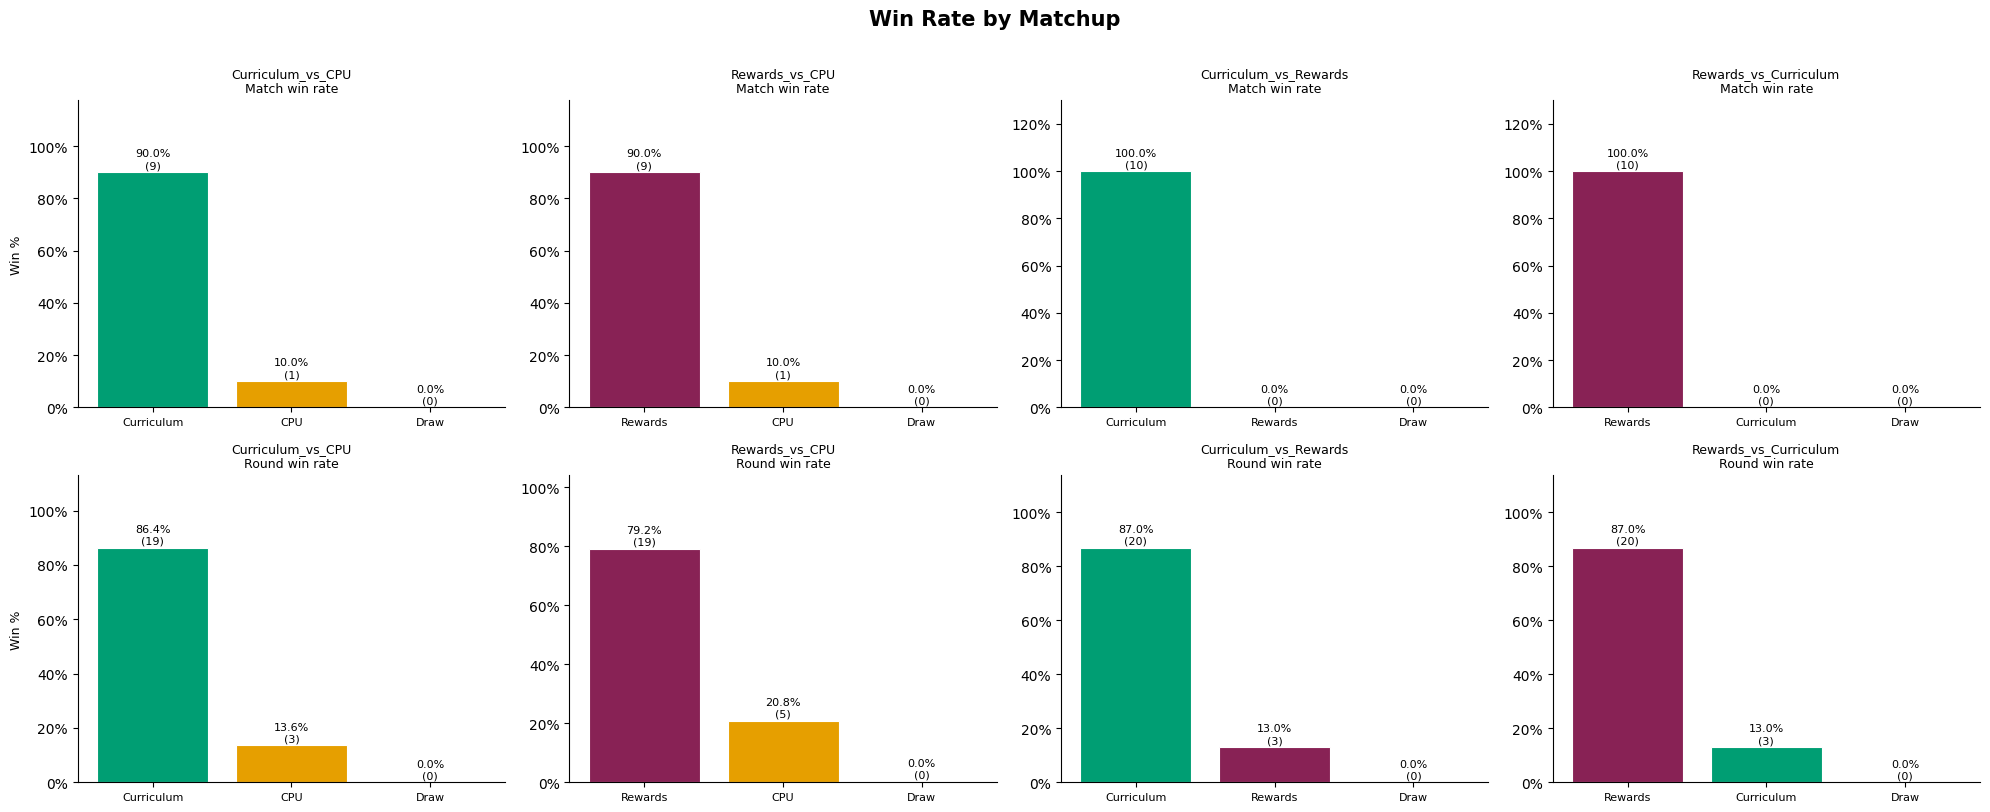

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
fig.suptitle("Win Rate by Matchup", fontsize=15, fontweight="bold", y=1.01)

for col, mu in enumerate(MATCHUPS):
    for row, level in enumerate(["match", "round"]):
        ax   = axes[row][col]
        row_ = summary_df[(summary_df.matchup == mu) & (summary_df.level == level)].iloc[0]

        labels = [row_["p1_name"], row_["p2_name"], "Draw"]
        vals   = [row_["p1_win_pct"], row_["p2_win_pct"], row_["draw_pct"]]
        counts = [row_["p1_wins"],    row_["p2_wins"],    row_["draws"]]
        colors = [PLAYER_COLORS.get(lbl, "#aaaaaa") for lbl in labels]

        bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=0.8)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8,
                    f"{bar.get_height():.1f}%\n({cnt})",
                    ha="center", va="bottom", fontsize=8)

        ax.set_ylim(0, max(vals) * 1.25 + 5)
        ax.set_ylabel("Win %" if col == 0 else "", fontsize=9)
        ax.set_title(f"{mu}\n{level.capitalize()} win rate", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.tick_params(axis="x", labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/winrate_by_matchup.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2 — Action Distributions

In [4]:
BUTTONS = ['B', 'A', 'MODE', 'START', 'UP', 'DOWN', 'LEFT', 'RIGHT', 'C', 'Y', 'X', 'Z']

SF_COMBOS_BUTTONS = [
    [['DOWN'], ['DOWN', 'RIGHT'], ['RIGHT'], ['X']],  # Hadouken facing right
    [['RIGHT'], ['DOWN'], ['DOWN', 'RIGHT'], ['X']],  # Shoryuken facing right
    [['DOWN'], ['DOWN', 'LEFT'], ['LEFT'], ['A']],    # Tatsumaki facing right
    [['DOWN'], ['DOWN', 'LEFT'], ['LEFT'], ['X']],    # Hadouken facing left
    [['LEFT'], ['DOWN'], ['DOWN', 'LEFT'], ['X']],    # Shoryuken facing left
    [['DOWN'], ['DOWN', 'RIGHT'], ['RIGHT'], ['A']],  # Tatsumaki facing left
]

DIRECTIONS_BUTTONS = [
    [],                              # No direction (neutral)
    ['UP'], ['DOWN'],
    ['LEFT'], ['RIGHT'],
    ['UP', 'LEFT'],
    ['UP', 'RIGHT'],
    ['DOWN', 'LEFT'],  # crouching block
    ['DOWN', 'RIGHT'], # crouching block
]

ATTACKS_BUTTONS = [
    [],           # No attack (neutral)
    ['B'], ['A'], ['C'],  # Light / medium / strong punch (Genesis mapping)
    ['Y'], ['X'], ['Z'],  # Light / medium / strong kick
]

In [5]:
COMBO_NAMES = {
    0: "Hadouken",
    1: "Shoryuken",
    2: "Tatsumaki",
    3: "Hadouken",
    4: "Shoryuken",
    5: "Tatsumaki",
}

_combo_re = re.compile(r"\s*\[combo (\d+)\]$")

def label_action(s):
    m = _combo_re.search(s)
    if m:
        return COMBO_NAMES.get(int(m.group(1)), _combo_re.sub("", s))
    return s

actions["display_action"] = actions["action"].apply(label_action)

def top_actions(matchup, player_name):
    """Return all actions sorted by count, with START filtered out. No truncation."""
    sl  = actions[(actions.matchup == matchup) & (actions.player_name == player_name)]
    agg = sl.groupby("display_action")["count"].sum().sort_values(ascending=False)
    return agg[~agg.index.str.contains("START")]

def plot_action_dist(ax, matchup, player_name, color, top_n=None, figure_letter=None):
    all_data = top_actions(matchup, player_name)
    total    = all_data.sum()
    data     = all_data.head(top_n or TOP_N_ACTIONS)
    pcts     = 100 * data / total
    bars = ax.barh(range(len(pcts)), pcts.values, color=color, edgecolor="white", linewidth=0.5, height=0.4)
    ax.set_yticks(range(len(pcts)))
    ax.set_yticklabels(pcts.index, fontsize=14)
    ax.invert_yaxis()
    xlabel = f"({figure_letter}) % of all steps" if figure_letter else "% of all actions"
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_title(f"{player_name}  ({matchup})", fontsize=16, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.spines[["top", "right"]].set_visible(False)
    for bar, pct_val in zip(bars, pcts.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{pct_val:.1f}%", va="center", fontsize=12)
    ax.set_xlim(0, pcts.max() * 1.18)
    return ax

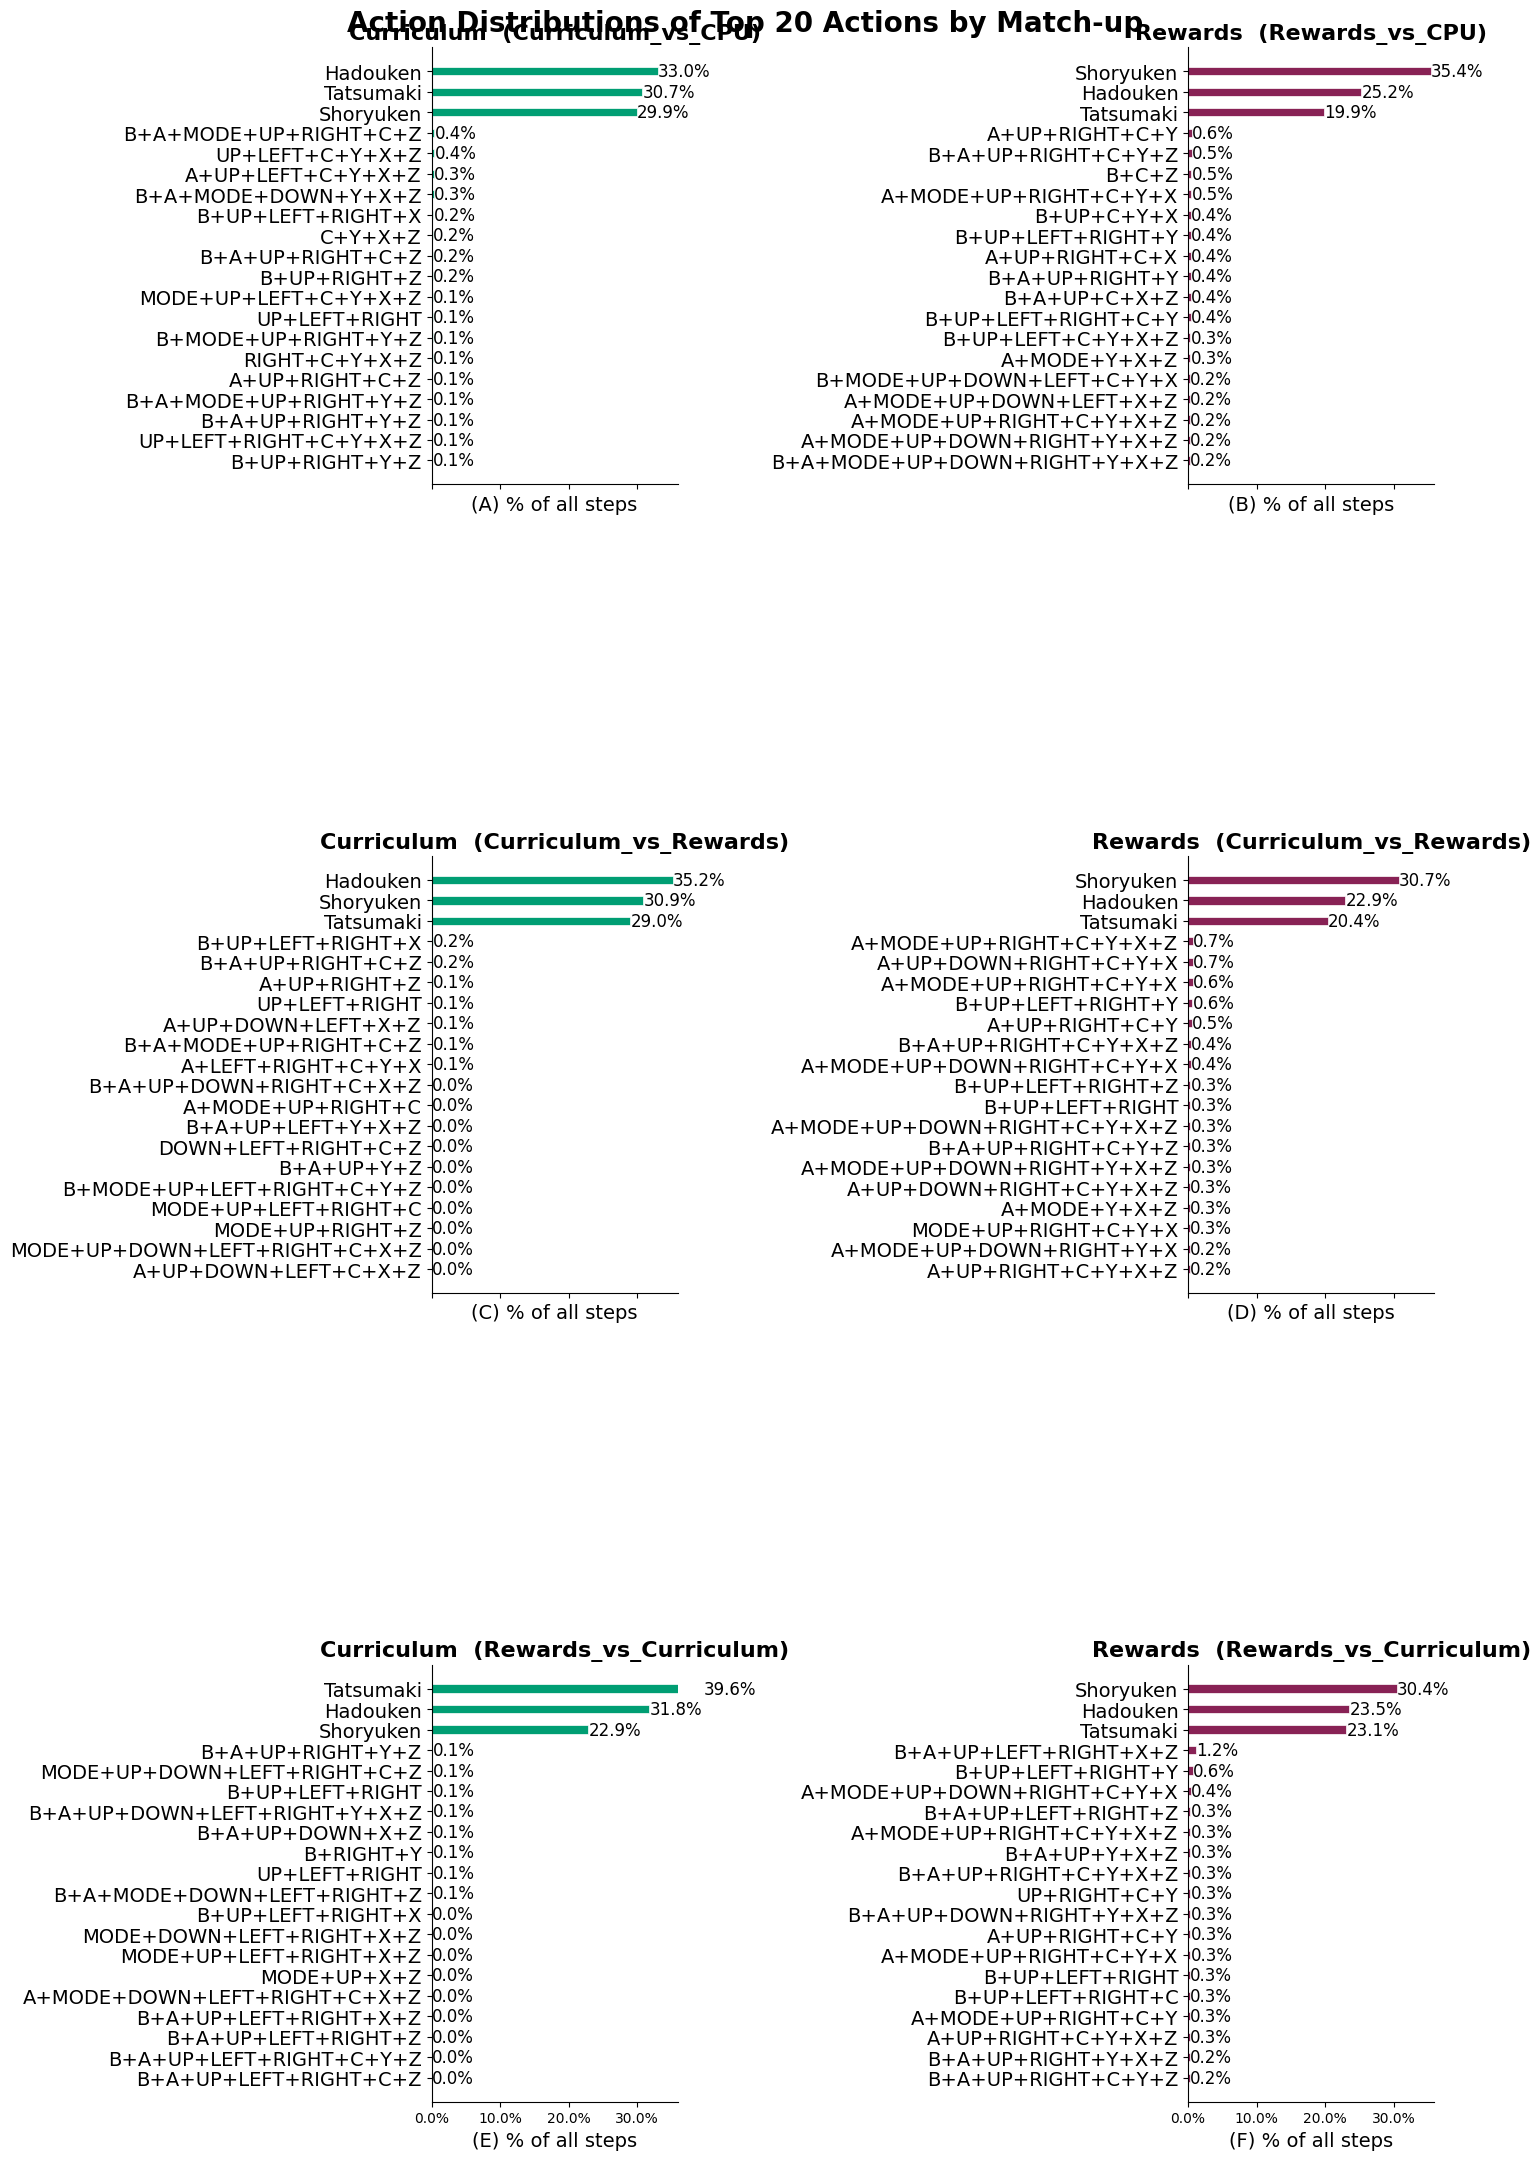

In [6]:
n_rows = TOP_N_ACTIONS
row_height = 0.5  # inches per bar
fig, axes = plt.subplots(3, 2, figsize=(15, n_rows * row_height * 2 + 2), sharex=True)

fig.suptitle(f"Action Distributions of Top {TOP_N_ACTIONS} Actions by Match-up", fontsize=20, fontweight="bold")

configs = [
    ("Curriculum_vs_CPU",     "Curriculum", PLAYER_COLORS["Curriculum"], "A"),
    ("Rewards_vs_CPU",        "Rewards",    PLAYER_COLORS["Rewards"],    "B"),
    ("Curriculum_vs_Rewards", "Curriculum", PLAYER_COLORS["Curriculum"], "C"),
    ("Curriculum_vs_Rewards", "Rewards",    PLAYER_COLORS["Rewards"],    "D"),
    ("Rewards_vs_Curriculum", "Curriculum", PLAYER_COLORS["Curriculum"], "E"),
    ("Rewards_vs_Curriculum", "Rewards",    PLAYER_COLORS["Rewards"],    "F"),
]

for ax, (matchup, player, color, letter) in zip(axes.flat, configs):
    plot_action_dist(ax, matchup, player, color, figure_letter=letter)

plt.tight_layout()
fig.subplots_adjust(hspace=0.85)
fig.savefig(f"{FIGURES_DIR}/action_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
TOP_TABLE = 3  # number of individually listed actions before collapsing into "Other Moves"

table_rows = []
for matchup, player, _, letter in configs:
    all_data = top_actions(matchup, player)
    total    = all_data.sum()
    pcts     = 100 * all_data / total
    row      = {"": letter, "Matchup": matchup, "Player": player}
    for i, (action, pct) in enumerate(pcts.head(TOP_TABLE).items(), 1):
        row[f"Top {i}"] = f"{action} ({pct:.1f}%)"
    row["Other Moves"] = f"{pcts.iloc[TOP_TABLE:].sum():.1f}%"
    table_rows.append(row)

pd.DataFrame(table_rows).set_index("")

,Matchup,Player,Top 1,Top 2,Top 3,Other Moves
,,,,,,
A,Curriculum_vs_CPU,Curriculum,Hadouken (33.0%),Tatsumaki (30.7%),Shoryuken (29.9%),6.4%
B,Rewards_vs_CPU,Rewards,Shoryuken (35.4%),Hadouken (25.2%),Tatsumaki (19.9%),19.5%
C,Curriculum_vs_Rewards,Curriculum,Hadouken (35.2%),Shoryuken (30.9%),Tatsumaki (29.0%),4.9%
D,Curriculum_vs_Rewards,Rewards,Shoryuken (30.7%),Hadouken (22.9%),Tatsumaki (20.4%),26.0%
E,Rewards_vs_Curriculum,Curriculum,Tatsumaki (39.6%),Hadouken (31.8%),Shoryuken (22.9%),5.7%
F,Rewards_vs_Curriculum,Rewards,Shoryuken (30.4%),Hadouken (23.5%),Tatsumaki (23.1%),23.0%


---
## 3 — Final Health Difference Histograms

**Value = P1 (left) final HP − P2 (right) final HP.**  
Positive → left player survived with more health.  Negative → right player survived with more health.  
Max range: −176 (left KO'd, right at full HP) to +176 (right KO'd, left at full HP).

In [8]:
rounds.loc[rounds["p1_hp_final"] < 0, "p1_hp_final"] = 0
rounds.loc[rounds["p2_hp_final"] < 0, "p2_hp_final"] = 0

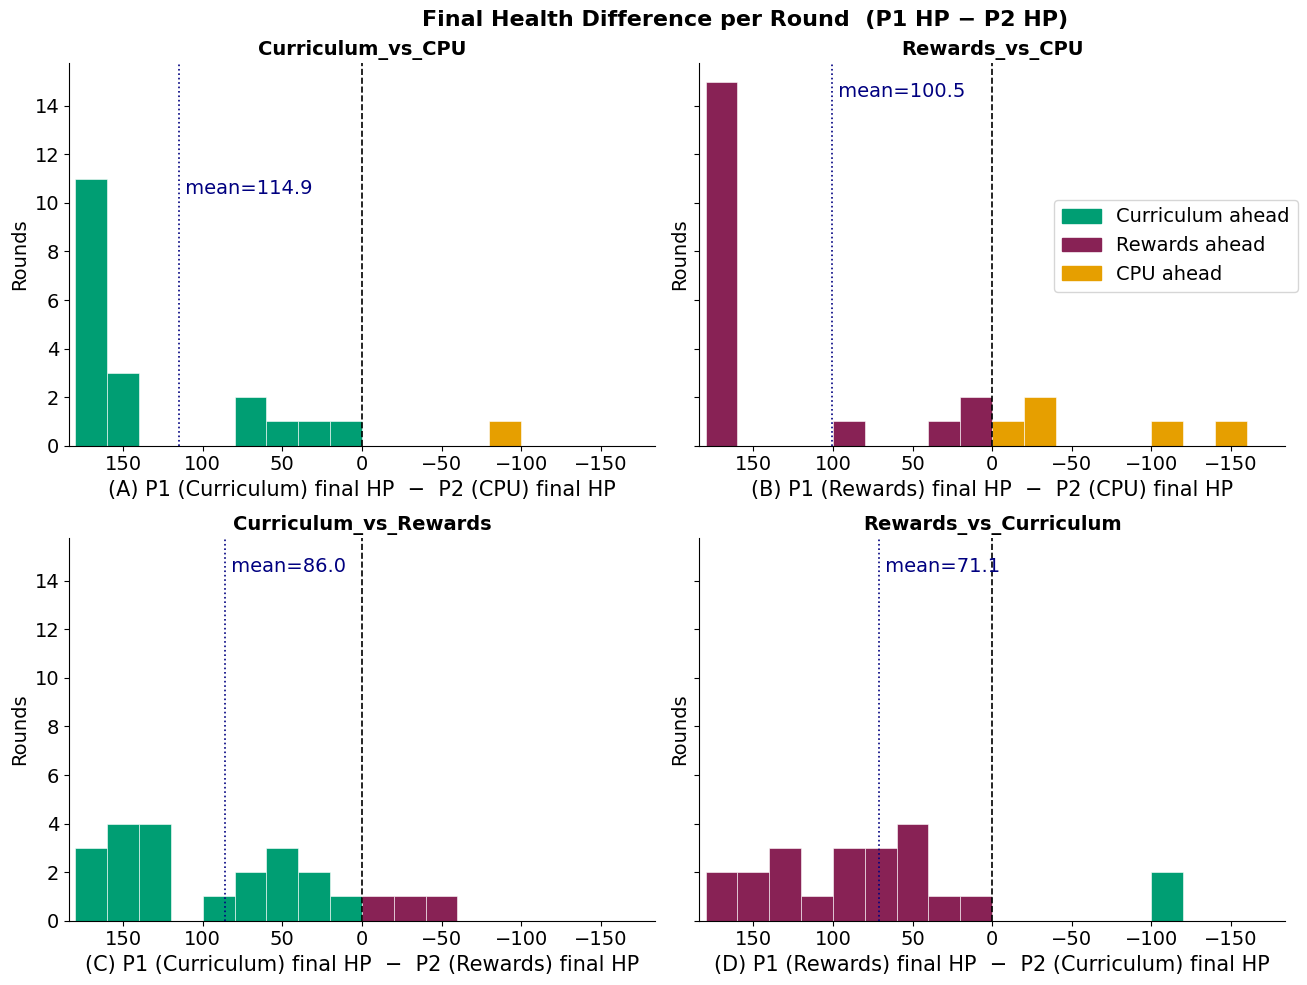

In [9]:
rounds["hp_diff"] = rounds["p1_hp_final"] - rounds["p2_hp_final"]

def plot_hp_diff(ax, matchup, color_left, color_right, figure_letter):
    p1_name, p2_name = matchup.split("_vs_")
    sl = rounds[rounds.matchup == matchup]["hp_diff"]
    bins = np.arange(-FULL_HP - 4, FULL_HP + 8, 20)
    pos = sl[sl > 0]
    neg = sl[sl < 0]
    if len(pos):
        ax.hist(pos, bins=bins, color=color_left,  edgecolor="white", linewidth=0.4)
    if len(neg):
        ax.hist(neg, bins=bins, color=color_right, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.axvline(sl.mean(), color="navy", linewidth=1.2, linestyle=":")
    ax.text(sl.mean(), ax.get_ylim()[1] * 0.95, f" mean={sl.mean():.1f}",
            color="navy", fontsize=14, ha="left", va="top")
    ax.set_xlabel(f"({figure_letter}) P1 ({p1_name}) final HP  −  P2 ({p2_name}) final HP", fontsize=15)
    ax.set_ylabel("Rounds", fontsize=14)
    ax.set_title(matchup, fontsize=14, fontweight="bold")
    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(FULL_HP + 8, -FULL_HP - 8)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Final Health Difference per Round  (P1 HP − P2 HP)",
             fontsize=16, fontweight="bold")

configs = [
    ("Curriculum_vs_CPU",     PLAYER_COLORS["Curriculum"], PLAYER_COLORS["CPU"]),
    ("Rewards_vs_CPU",        PLAYER_COLORS["Rewards"],    PLAYER_COLORS["CPU"]),
    ("Curriculum_vs_Rewards", PLAYER_COLORS["Curriculum"], PLAYER_COLORS["Rewards"]),
    ("Rewards_vs_Curriculum", PLAYER_COLORS["Rewards"],    PLAYER_COLORS["Curriculum"]),
]
figure_letters = ["A", "B", "C", "D"]
for i, (ax, (mu, cl, cr)) in enumerate(zip(axes.flat, configs)):
    plot_hp_diff(ax, mu, cl, cr, figure_letters[i])

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=PLAYER_COLORS["Curriculum"], label="Curriculum ahead"),
    mpatches.Patch(color=PLAYER_COLORS["Rewards"],    label="Rewards ahead"),
    mpatches.Patch(color=PLAYER_COLORS["CPU"],        label="CPU ahead"),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=14, bbox_to_anchor=(0.875, 0.8))
plt.tight_layout(rect=[0, 0, 0.87, 1])
fig.savefig(f"{FIGURES_DIR}/hp_diff_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

  Curriculum_vs_CPU
    Match winrate  — Curriculum: 100.0% (3/3)   CPU: 0.0% (0/3)
    Round winrate  — Curriculum: 100.0% (6/6)   CPU: 0.0% (0/6)

  Rewards_vs_CPU
    Match winrate  — Rewards: 100.0% (3/3)   CPU: 0.0% (0/3)
    Round winrate  — Rewards: 66.7% (6/9)   CPU: 33.3% (3/9)

  Curriculum_vs_Rewards
    Match winrate  — Curriculum: 100.0% (3/3)   Rewards: 0.0% (0/3)
    Round winrate  — Curriculum: 100.0% (6/6)   Rewards: 0.0% (0/6)

  Rewards_vs_Curriculum
    Match winrate  — Rewards: 100.0% (3/3)   Curriculum: 0.0% (0/3)
    Round winrate  — Rewards: 100.0% (6/6)   Curriculum: 0.0% (0/6)
